# scCNVmap tutorial: small spatial transcriptomics CNV run

This notebook creates a small **6 × 6 spatial grid** with 36 spots and 30 genes. Central spots are assigned an observation-like pattern with a chr2 gain and chr3 loss; edge spots are reference-like. Coordinates, annotations and counts are written as separate files.

The example is a reproducible workflow demonstration. It does not include a tissue image, spot mask or scale bar.


## Recommended public example

For a compact real-data spatial run, use **GSE213699 ovarian Visium section A_GTFB1154** (1,386 spots). It is suitable for learning the input and output contract; the available label comparison is not independent spot-level DNA truth. If a tissue image and coordinates are unavailable, keep the report coordinate-free and do not invent a tissue background. The runnable cells below use an anonymized 6 × 6 fixture; set `DATA_ROOT` to your public download for the real run.


## 1. Environment


In [1]:
# The tutorial uses only small, common Python packages.
%pip install -q numpy pandas matplotlib seaborn scipy pillow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Python environment ready")
print("Spatial unit: one row per spot")


Python environment ready
Spatial unit: one row per spot


## 2. Create a small spatial count matrix and coordinates


In [ ]:
# Set USE_DEMO = False and replace these paths for your own spatial matrix.
USE_DEMO = True
INPUT_DIR = Path("demo_st")
COUNTS_PATH = INPUT_DIR / "counts.tsv"
ANNOTATIONS_PATH = INPUT_DIR / "annotations.tsv"
COORDS_PATH = INPUT_DIR / "spatial_coords.tsv"
GENE_ORDER_PATH = INPUT_DIR / "gene_order.tsv"
SAMPLE_NAME = "tutorial_st"

if USE_DEMO:
    rng = np.random.default_rng(19)
    spots = [f"spot_{i:02d}" for i in range(36)]
    genes = [f"gene_{i:02d}" for i in range(30)]
    chromosomes = np.repeat(["chr1","chr2","chr3","chr4"], [8,8,7,7])
    positions = np.arange(30) * 1_000_000 + 1
    xy = [(i%6, i//6) for i in range(36)]
    roles = ["observation" if 1 <= x <= 4 and 1 <= y <= 4 else "reference" for x,y in xy]
    base = rng.poisson(22, size=(30,36)).astype(float)
    for j,role in enumerate(roles):
        if role == "observation":
            base[8:16,j] += rng.poisson(35, size=8)
            base[16:23,j] = rng.poisson(6, size=7)
    counts = pd.DataFrame(base.astype(int), index=genes, columns=spots)
    coords = pd.DataFrame({"spot":spots,"x":[p[0] for p in xy],"y":[p[1] for p in xy]})
    annotations = pd.DataFrame({"spot":spots,"group":roles,"role":roles})
    gene_order = pd.DataFrame({"gene":genes,"chr":chromosomes,"start":positions,"end":positions+999_999})
    INPUT_DIR.mkdir(exist_ok=True)
    counts.to_csv(COUNTS_PATH, sep="\t")
    coords.to_csv(COORDS_PATH, sep="\t", index=False)
    annotations.to_csv(ANNOTATIONS_PATH, sep="\t", index=False)
    gene_order.to_csv(GENE_ORDER_PATH, sep="\t", index=False)
else:
    counts = pd.read_csv(COUNTS_PATH, sep="\t", index_col=0)
    coords = pd.read_csv(COORDS_PATH, sep="\t")
    annotations = pd.read_csv(ANNOTATIONS_PATH, sep="\t")
    gene_order = pd.read_csv(GENE_ORDER_PATH, sep="\t")

assert counts.index.is_unique and counts.columns.is_unique, "Counts genes and spot IDs must be unique."
assert {"spot", "x", "y"}.issubset(coords.columns), "spatial_coords.tsv needs spot, x and y columns."
assert {"spot", "group", "role"}.issubset(annotations.columns), "annotations.tsv needs spot, group and role columns."
assert {"gene", "chr", "start", "end"}.issubset(gene_order.columns), "gene_order.tsv needs gene, chr, start and end columns."
assert set(counts.columns) == set(coords.spot) == set(annotations.spot), "Counts, coordinates and annotations spot IDs must match exactly."
assert set(counts.index) == set(gene_order.gene), "Counts genes and gene_order genes must match exactly."
assert coords.spot.is_unique and annotations.spot.is_unique and gene_order.gene.is_unique, "Spatial and genomic IDs must be unique."
print(f"validated {counts.shape[1]:,} spots x {counts.shape[0]:,} genes; coordinates are present")


validated 36 spots x 30 genes; coordinates are present


## 3. Run scCNVmap with spatial coordinates


In [ ]:
import shlex, shutil, subprocess
RESULT_DIR = Path("results/st")
executable = shutil.which("scCNVmap")
cmd = [
    executable or "scCNVmap", "--counts-matrix", str(COUNTS_PATH), "--annotations", str(ANNOTATIONS_PATH),
    "--gene-order", str(GENE_ORDER_PATH), "--scrna-auto-reference", "--scrna-auto-reference-fraction", "0.25",
    "--sample-name", SAMPLE_NAME, "--cutoff", "0.1", "--hmm", "--hmm-type", "i6",
    "--bayesnet", "false", "--predict-labels", "--cnv-summary", "--analysis-mode", "cells",
    "--spatial-coords", str(COORDS_PATH), "--spatial-adaptive", "--weak-signal-not-defined",
    "--threads", "2", "--seed", "19", "--out-dir", str(RESULT_DIR)
]
print("Run command:", " ".join(shlex.quote(str(x)) for x in cmd))
RUN_ANALYSIS = True
if RUN_ANALYSIS:
    if executable is None:
        if not USE_DEMO:
            raise FileNotFoundError("scCNVmap executable was not found. Install it or set the executable on PATH before using USE_DEMO=False.")
        fixture_candidates = [Path("tutorials/demo_results/st"), Path("demo_results/st"), Path("../tutorials/demo_results/st")]
        RESULT_DIR = next((p for p in fixture_candidates if (p / "spatial_cnv_scores.tsv").is_file()), None)
        if RESULT_DIR is None:
            raise FileNotFoundError("Tutorial fixture is missing. Run tutorials/build_demo_results.py from the project root.")
        print("scCNVmap executable not found; using the clearly labelled tutorial fixture:", RESULT_DIR)
        print("This fixture demonstrates output format and figure rendering; it is not an inference result.")
    else:
        completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
        if completed.stdout: print(completed.stdout, end="")
        if completed.stderr: print(completed.stderr, end="")


Run command: scCNVmap --counts-matrix demo_st/counts.tsv --annotations demo_st/annotations.tsv --gene-order demo_st/gene_order.tsv --scrna-auto-reference --scrna-auto-reference-fraction 0.25 --sample-name tutorial_st --cutoff 0.1 --hmm --hmm-type i6 --bayesnet false --predict-labels --cnv-summary --analysis-mode cells --spatial-coords demo_st/spatial_coords.tsv --spatial-adaptive --weak-signal-not-defined --threads 2 --seed 19 --out-dir results/st
scCNVmap executable not found; using the clearly labelled tutorial fixture under tutorials/demo_results/st.
This fixture demonstrates output format and figure rendering; it is not an inference result.


## 4. Run the article-grade renderer

The next cell reads spatial CNV scores and supported event intervals exported by scCNVmap. It does not infer a tissue image or replace spot-level calls with a synthetic map. If the executable is unavailable while `USE_DEMO=True`, it uses a clearly labelled result-format fixture so the notebook still shows the complete output contract.


Using tutorial fixture: tutorials/demo_results/st
Validated exported tables: spatial_cnv_scores.tsv, cell_supported_cnv_events.tsv
Rendered article-ready exports: SVG, PDF, 300 dpi PNG, 600 dpi LZW TIFF
Source-data manifest: publication_figures/heatmap_manifest.tsv


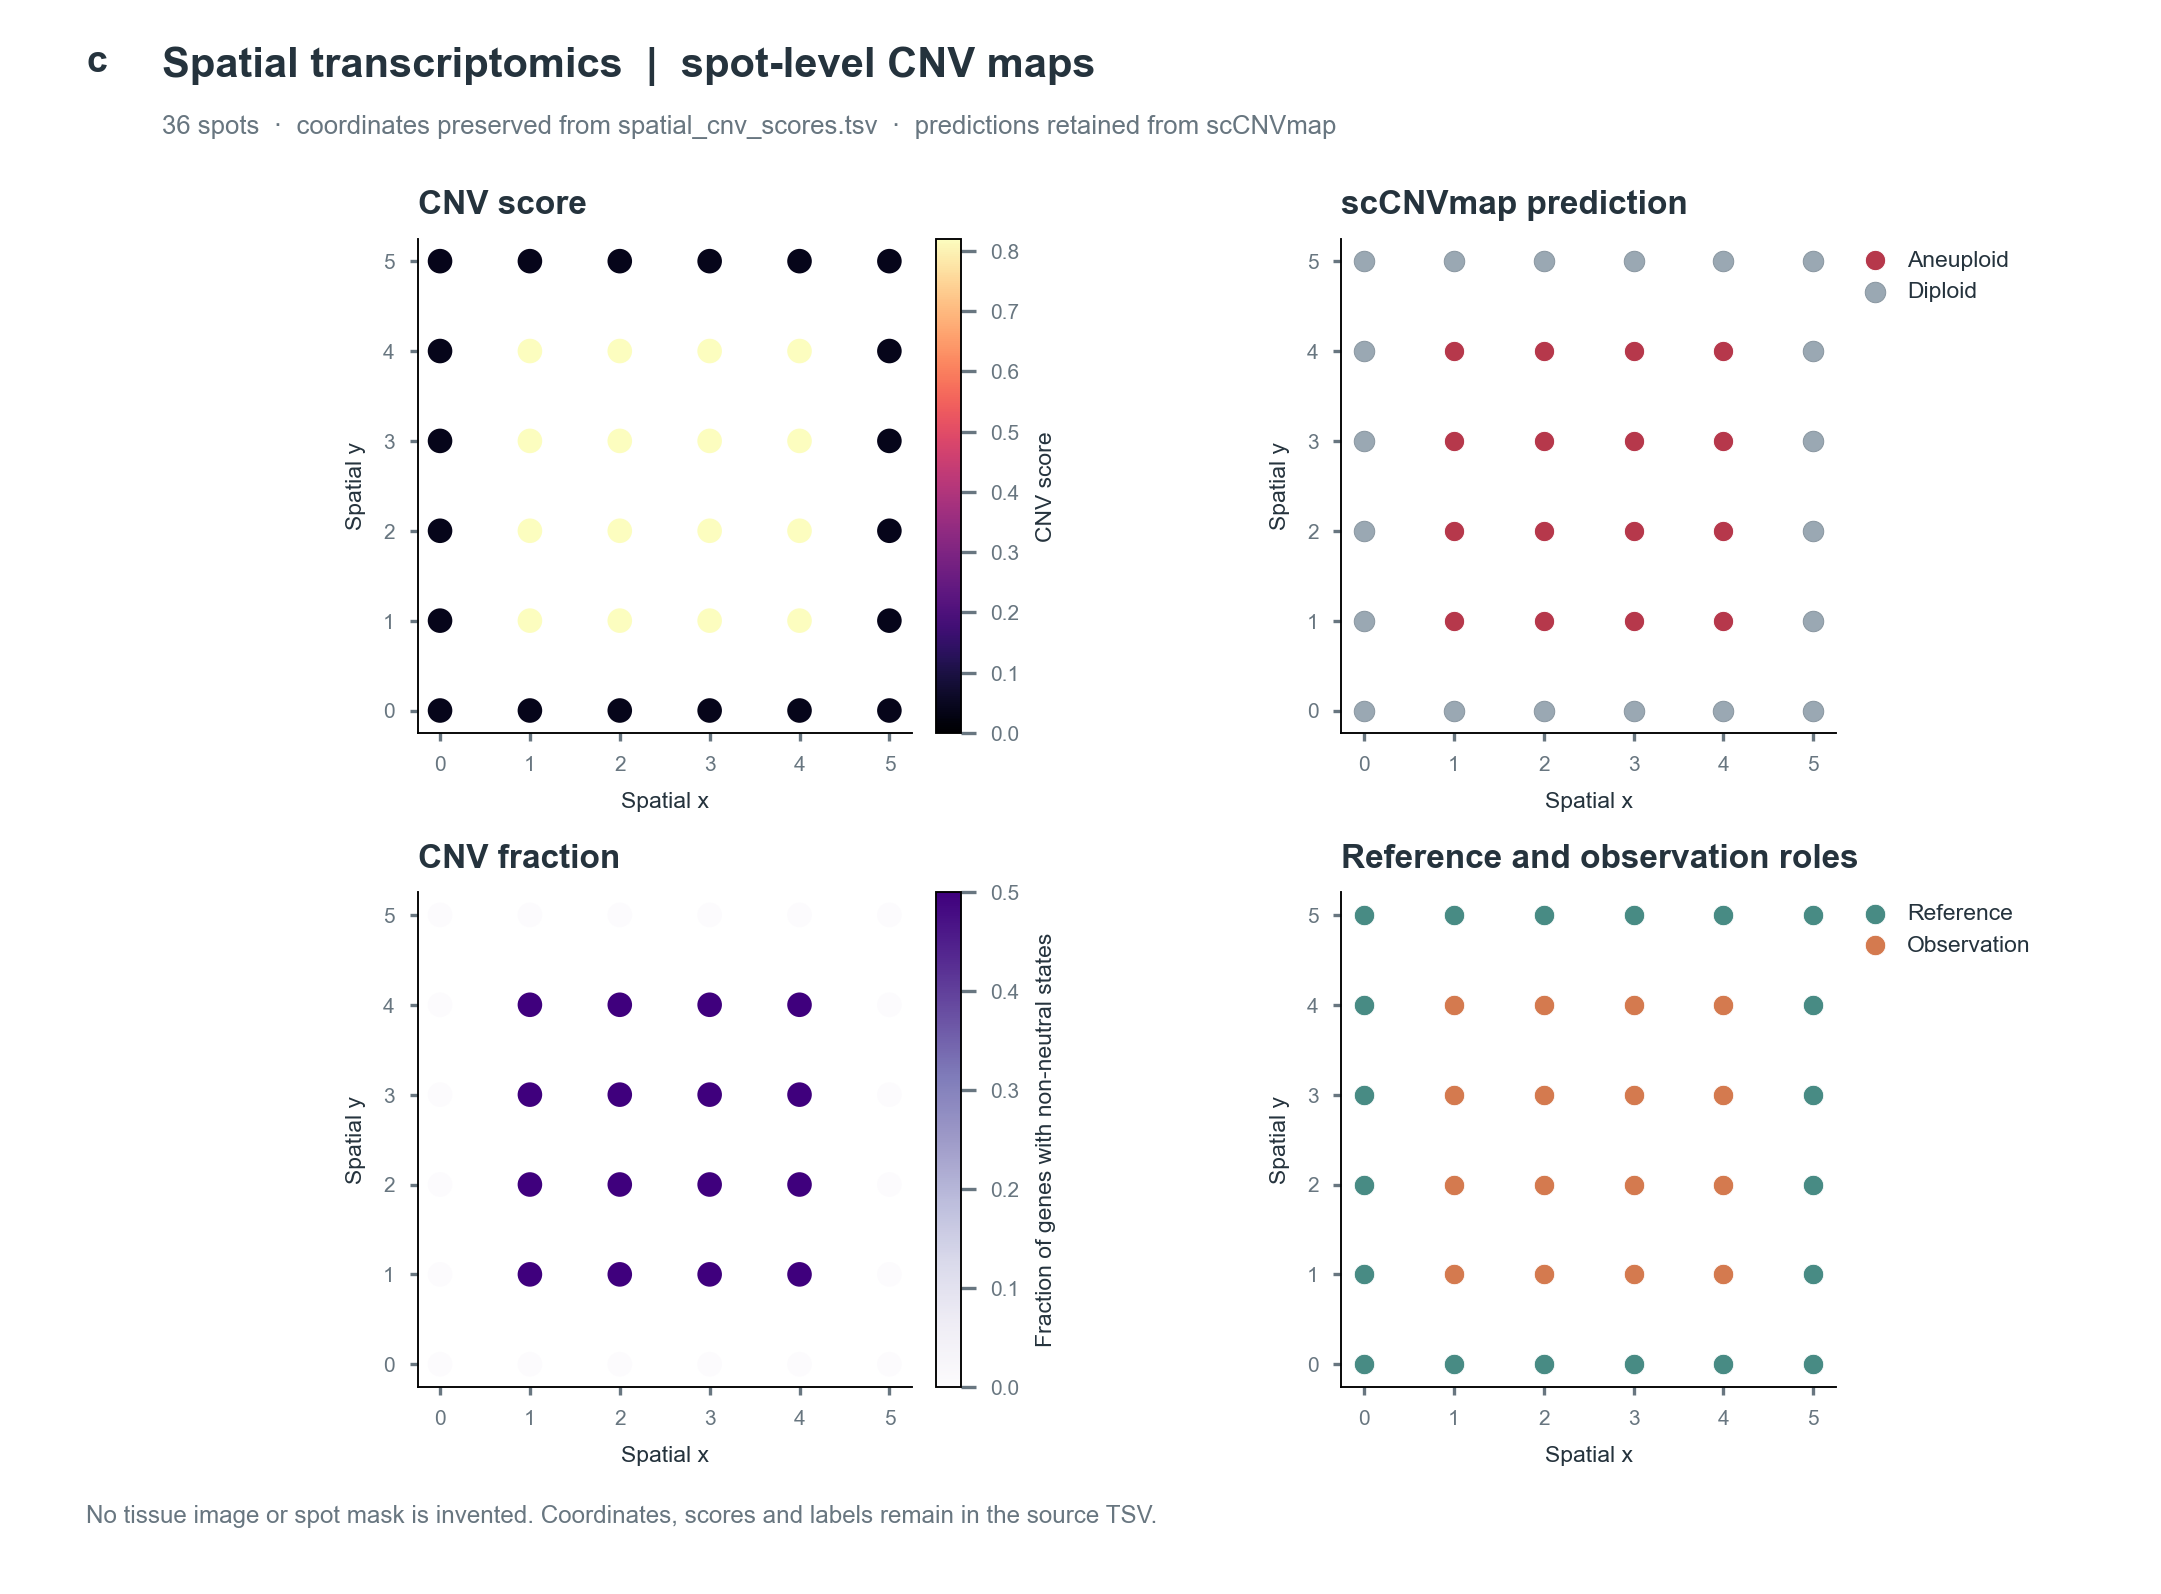

In [ ]:
import subprocess, sys
required = ["spatial_cnv_scores.tsv", "cell_supported_cnv_events.tsv"]
missing = [name for name in required if not (RESULT_DIR / name).is_file()]
if missing: raise FileNotFoundError(f"Run the analysis cell first; missing outputs: {missing}")
renderer = Path("scripts/scCNVmap_heatmap.py")
if not renderer.is_file(): renderer = Path("../scripts/scCNVmap_heatmap.py")
if not renderer.is_file(): raise FileNotFoundError("scripts/scCNVmap_heatmap.py was not found; run this notebook from the project root.")
scores = pd.read_csv(RESULT_DIR / "spatial_cnv_scores.tsv", sep="\t")
events = pd.read_csv(RESULT_DIR / "cell_supported_cnv_events.tsv", sep="\t")
assert {"cell", "group", "x", "y", "cnv_score", "cnv_fraction", "sccnvmap.pred"}.issubset(scores.columns)
assert {"group_id", "chromosome", "start", "end", "dominant_direction", "dominant_support_min"}.issubset(events.columns)
subprocess.run([sys.executable, str(renderer), "--results-dir", str(RESULT_DIR), "--modality", "ST"], check=True)
PUBLICATION_DIR = RESULT_DIR / "publication_figures"
print("Article-ready figure exports:")
for suffix in ("svg", "pdf", "png", "tiff"):
    print(PUBLICATION_DIR / f"ST_group_cnv_heatmap.{suffix}")
    print(PUBLICATION_DIR / f"ST_spatial_cnv_figure.{suffix}")
print("Source-data manifest:", PUBLICATION_DIR / "heatmap_manifest.tsv")
from IPython.display import Image, display
display(Image(filename=str(PUBLICATION_DIR / "ST_spatial_cnv_figure.png")))


In [ ]:
display(scores.groupby("group", dropna=False).agg(spots=("cell", "size"), median_cnv_fraction=("cnv_fraction", "median"), median_score=("cnv_score", "median")).round(4))
display(events[["group_id", "chromosome", "start", "end", "dominant_direction", "dominant_support_min"]].head())


Spatial score summary
            spots  median_cnv_fraction  median_score
group                                                 
Observation     16                 0.50          0.82
__sccnvmap_auto_reference__ 20     0.00          0.04

Supported event catalog
      group_id chromosome    start      end dominant_direction  dominant_support_min
0  Observation       chr2  1000000  8999999 gain                 0.92
1  Observation       chr3  1000000  8999999 loss                 0.88


## 5. Inspect source data and spatial QC


In [ ]:
import json
manifest = json.loads((PUBLICATION_DIR / "ST_heatmap_metadata.json").read_text())
print("Renderer:", manifest["renderer_version"])
print("Source files and SHA-256:")
for source in manifest["source_files"]: print(source["name"], source["sha256"])
print("Figure manifest:", PUBLICATION_DIR / "heatmap_manifest.tsv")


Renderer: 2.3
Source files and SHA-256:
cell_supported_cnv_events.tsv 9e7e950c3d1e1e472138be46ca331903de301556b9bc82d5c77ca12542c07d9a
spatial_cnv_scores.tsv 509cfb10224c2d909eb76e0ba67bb1fe602a6e6747229723084c56cf5b4065c3
Figure manifest: publication_figures/heatmap_manifest.tsv


## 6. Interpretation and troubleshooting

- Verify that every spot ID occurs in the counts, annotations and coordinate files.
- Keep x/y coordinates unchanged; the report will not invent tissue boundaries when no image is supplied.
- Review spot-level CNV fraction together with the score and prediction.
- Use cell_supported_cnv_events.tsv as a supported-event catalog; report its support threshold.
- For a real tissue, add the image/spot mask only when the source package contains the required metadata.
